In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import os

# Load datasets
data_path = 'data/raw/'
transactions = pd.read_csv(os.path.join(data_path, 'transactions_train.csv'))
articles = pd.read_csv(os.path.join(data_path, 'articles.csv'))
customers = pd.read_csv(os.path.join(data_path, 'customers.csv'))

# Convert date
transactions['t_dat'] = pd.to_datetime(transactions['t_dat'])

# Set up visualization
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

print("✓ Data loaded successfully!")
print(f"Transactions: {transactions.shape}")
print(f"Articles: {articles.shape}")

✓ Data loaded successfully!
Transactions: (31788324, 5)
Articles: (105542, 25)


ARTICLE POPULARITY ANALYSIS

1. OVERALL POPULARITY METRICS:
 Total Unique Articles : 104,547
 Mean purchases for per article : 304.06
 Median purchases for per article : 65
 Min: 1
 Max: 50287
 Standard Deviation : 791.266060

2. POPULARITY DISTRIBUTION:
   Articles with 1 purchase: 4,491
   Articles with 2-10 purchases: 17,986
   Articles with 11-50 purchases: 25,374
   Articles with 51-100 purchases: 12,230
   Articles with 100+ purchases: 44,466

3. TOP 50 MOST POPULAR ARTICLES:
    1.  706016001 | 50287 purchases | Jade HW Skinny Denim TRS
    2.  706016002 | 35043 purchases | Jade HW Skinny Denim TRS
    3.  372860001 | 31718 purchases | 7p Basic Shaftless
    4.  610776002 | 30199 purchases | Tilly (1)
    5.  759871002 | 26329 purchases | Tilda tank
    6.  464297007 | 25025 purchases | Greta Thong Mynta Low 3p
    7.  372860002 | 24458 purchases | 7p Basic Shaftless
    8.  610776001 | 22451 purchases | Tilly (1)
    9.  399223001 | 22236 purchases | Curvy Jeggings HW Ankle
   

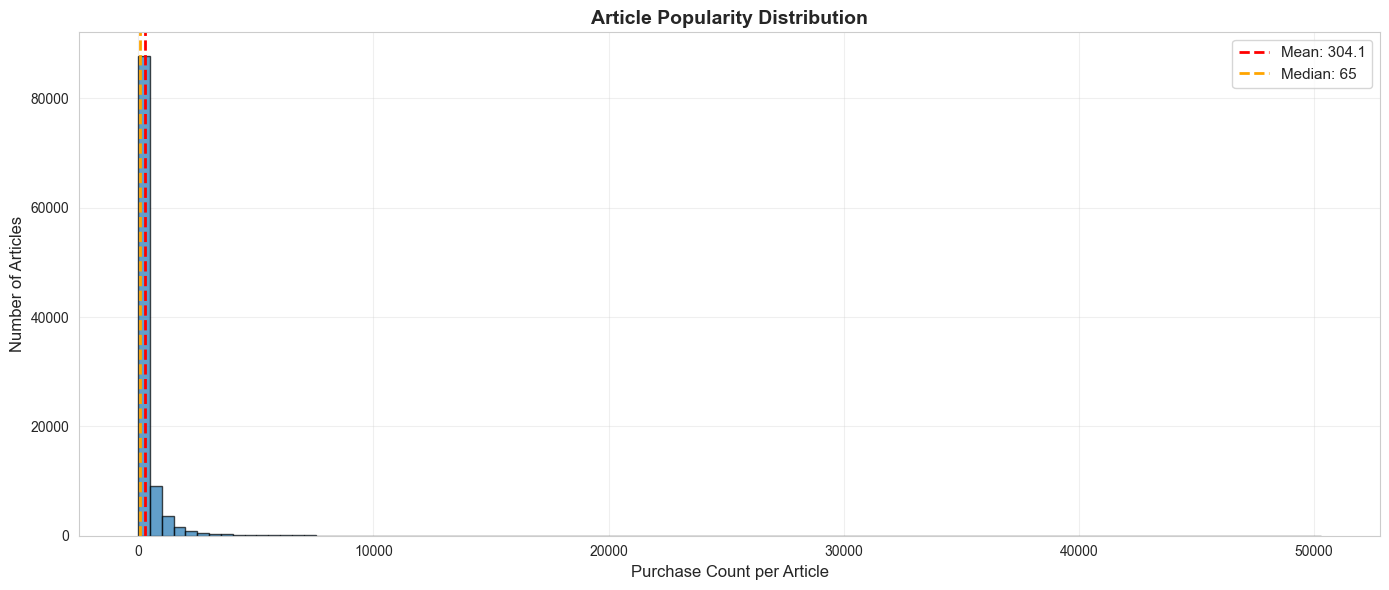

Skewness: 12.83

4. ARTICLES SOLD ONLY ONCE (DEAD STOCK):
   Total articles with only 1 purchase: 4,491 (4.3%)

   Sample of one-time articles:
    1.  126589012 | 2p Claw
    2.  141661025 | Velour pyjama
    3.  156610007 | Anton sport pant
    4.  174057026 | FLEECE PYJAMA
    5.  176550021 | Sleep bag padded
    6.  187949016 | Padded pyjama
    7.  189634031 | Long Leg Leggings
    8.  189691051 | Carolina sweater (1)
    9.  190252020 | Chris 3pk solid
   10.  203027048 | Linni tee (1)
   11.  203595036 | Bryn Flanel Check
   12.  203595048 | Bryn Flanel Check
   13.  203595058 | Bryn Flanel Check
   14.  212042070 | Mimmi sneaker
   15.  212629031 | Alcazar strap dress

5. QUARTILE ANALYSIS (Article Popularity):
   Q1 (25%):  14 purchases
   Q2 (50%):  65 purchases (MEDIAN)
   Q3 (75%):  286 purchases
   Q4 (90%):  793 purchases
   Q5 (95%):  1318 purchases

6. PARETO ANALYSIS (80/20 RULE):
   Top 10% articles (10,454 articles): 60.7% of all purchases
   Bottom 90% articles: 39.

In [10]:
print("=" * 70)
print("ARTICLE POPULARITY ANALYSIS")
print("=" * 70)

# 1. Article popularity (how many times purchased)
article_popularity = transactions.groupby('article_id').size().reset_index(name = 'purchase_count')
article_popularity = article_popularity.merge(articles[['article_id', 'prod_name', 'product_type_name', 'department_name']],
                                             on = 'article_id',
                                             how = 'left')
print(f"\n1. OVERALL POPULARITY METRICS:")
print(f" Total Unique Articles : {len(article_popularity):,}")
print(f" Mean purchases for per article : {article_popularity['purchase_count'].mean():.2f}")
print(f" Median purchases for per article : {article_popularity['purchase_count'].median():.0f}")
print(f" Min: {article_popularity['purchase_count'].min()}")
print(f" Max: {article_popularity['purchase_count'].max()}")
print(f" Standard Deviation : {article_popularity['purchase_count'].std():2f}")

# 2. Distribution
print(f"\n2. POPULARITY DISTRIBUTION:")
print(f"   Articles with 1 purchase: {(article_popularity['purchase_count'] == 1).sum():,}")
print(f"   Articles with 2-10 purchases: {((article_popularity['purchase_count'] >= 2) & (article_popularity['purchase_count'] <= 10)).sum():,}")
print(f"   Articles with 11-50 purchases: {((article_popularity['purchase_count'] >= 11) & (article_popularity['purchase_count'] <= 50)).sum():,}")
print(f"   Articles with 51-100 purchases: {((article_popularity['purchase_count'] >= 51) & (article_popularity['purchase_count'] <= 100)).sum():,}")
print(f"   Articles with 100+ purchases: {(article_popularity['purchase_count'] > 100).sum():,}")

# 3. Top articles
print(f"\n3. TOP 50 MOST POPULAR ARTICLES:")
top_articles = article_popularity.nlargest(50, 'purchase_count')
for idx, (i, row) in enumerate(top_articles.iterrows(), 1):
    print(f"   {idx:>2}. {row['article_id']:>10} | {row['purchase_count']:>5} purchases | {row['prod_name'][:50]}")

# Histogram
plt.figure(figsize=(14, 6))
plt.hist(article_popularity['purchase_count'], bins=100, edgecolor='black', alpha=0.7)
plt.xlabel('Purchase Count per Article', fontsize=12)
plt.ylabel('Number of Articles', fontsize=12)
plt.title('Article Popularity Distribution', fontsize=14, fontweight='bold')

plt.axvline(article_popularity['purchase_count'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {article_popularity["purchase_count"].mean():.1f}')
plt.axvline(article_popularity['purchase_count'].median(), color='orange', linestyle='--', linewidth=2, label=f'Median: {article_popularity["purchase_count"].median():.0f}')

plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Skewness: {article_popularity['purchase_count'].skew():.2f}")

# 4. Bottom articles (sold only once)
print(f"\n4. ARTICLES SOLD ONLY ONCE (DEAD STOCK):")
one_purchase_articles = article_popularity[article_popularity['purchase_count'] == 1]
print(f"   Total articles with only 1 purchase: {len(one_purchase_articles):,} ({len(one_purchase_articles)/len(article_popularity)*100:.1f}%)")
print(f"\n   Sample of one-time articles:")
for idx, (i, row) in enumerate(one_purchase_articles.head(15).iterrows(), 1):
    print(f"   {idx:>2}. {row['article_id']:>10} | {row['prod_name'][:50]}")

# 5. Articles by purchase frequency quartiles
print(f"\n5. QUARTILE ANALYSIS (Article Popularity):")
quartiles = article_popularity['purchase_count'].quantile([0.25, 0.5, 0.75, 0.9, 0.95])
print(f"   Q1 (25%):  {quartiles[0.25]:.0f} purchases")
print(f"   Q2 (50%):  {quartiles[0.50]:.0f} purchases (MEDIAN)")
print(f"   Q3 (75%):  {quartiles[0.75]:.0f} purchases")
print(f"   Q4 (90%):  {quartiles[0.90]:.0f} purchases")
print(f"   Q5 (95%):  {quartiles[0.95]:.0f} purchases")

# 6. Pareto Analysis (80/20 rule)
total_purchases = article_popularity['purchase_count'].sum()
top_10_pct_articles = len(article_popularity) * 0.10
top_10_articles = article_popularity.nlargest(int(top_10_pct_articles), 'purchase_count')
top_10_purchases = top_10_articles['purchase_count'].sum()
top_10_percentage = (top_10_purchases / total_purchases) * 100

print(f"\n6. PARETO ANALYSIS (80/20 RULE):")
print(f"   Top 10% articles ({int(top_10_pct_articles):,} articles): {top_10_percentage:.1f}% of all purchases")
print(f"   Bottom 90% articles: {100-top_10_percentage:.1f}% of all purchases")

# Find 80% threshold
cumsum = article_popularity.sort_values('purchase_count', ascending=False)['purchase_count'].cumsum()
cumsum_pct = (cumsum / total_purchases) * 100
articles_for_80pct = (cumsum_pct <= 80).sum()
print(f"\n   Articles needed for 80% of purchases: {articles_for_80pct:,} ({articles_for_80pct/len(article_popularity)*100:.1f}%)")

In [22]:
print("=" * 70)
print("PRODUCT CATEGORY ANALYSIS")
print("=" * 70)

# 1. Category distribution
print(f"\n1. CATEGORY DISTRIBUTION:")
category_dist = articles['product_type_name'].value_counts()
print(f"\n   Total unique product types: {len(category_dist)}")
print(f"\n   Top 15 Product Types:")
for idx, (category, count) in enumerate(category_dist.head(15).items(), 1):
    pct = (count / len(articles)) * 100
    print(f"   {idx:>2}. {category[:40]:40s} : {count:>5} ({pct:>5.1f}%)")

    # 2. Category by sales
print(f"\n\n2. CATEGORY SALES PERFORMANCE:")
category_sales = transactions.merge(articles[['article_id', 'product_type_name']], 
                                    on='article_id', 
                                    how='left')
category_sales_agg = category_sales.groupby('product_type_name').agg({
    'article_id': 'count',
    'price': 'sum'
}).reset_index()
category_sales_agg.columns = ['product_type_name', 'total_sales', 'total_revenue']
category_sales_agg = category_sales_agg.sort_values('total_sales', ascending=False)

print(f"\n   Top 15 Categories by Sales:")
for idx, row in category_sales_agg.head(15).iterrows():
    pct = (row['total_sales'] / len(transactions)) * 100
    print(f"   {row['product_type_name'][:40]:40s} : {row['total_sales']:>7,.0f} sales ({pct:>5.1f}%) | €{row['total_revenue']:>8.2f}")

# 3. Color preferences
print(f"\n\n3. COLOR PREFERENCES:")
color_dist = articles['colour_group_name'].value_counts()
print(f"\n   Total unique colors: {len(color_dist)}")
print(f"\n   Top 15 Colors:")
for idx, (color, count) in enumerate(color_dist.head(15).items(), 1):
    pct = (count / len(articles)) * 100
    print(f"   {idx:>2}. {color[:30]:30s} : {count:>5} ({pct:>5.1f}%)")

# 4. Color sales
print(f"\n\n4. COLOR SALES PERFORMANCE:")
color_sales = transactions.merge(articles[['article_id', 'colour_group_name']], 
                                 on='article_id', 
                                 how='left')
color_sales_agg = color_sales.groupby('colour_group_name').agg({
    'article_id': 'count'
}).reset_index()
color_sales_agg.columns = ['colour_group_name', 'total_sales']
color_sales_agg = color_sales_agg.sort_values('total_sales', ascending=False)

print(f"\n   Top 10 Colors by Sales:")
for idx, row in color_sales_agg.head(10).iterrows():
    pct = (row['total_sales'] / len(transactions)) * 100
    print(f"   {row['colour_group_name'][:20]:20s} : {row['total_sales']:>7,.0f} sales ({pct:>5.1f}%)")

# 5. Department analysis
print(f"\n\n5. DEPARTMENT ANALYSIS:")
dept_dist = articles['department_name'].value_counts()
print(f"\n   Total departments: {len(dept_dist)}")
print(f"\n   Top 10 Departments:")
for idx, (dept, count) in enumerate(dept_dist.head(10).items(), 1):
    pct = (count / len(articles)) * 100
    print(f"   {idx:>2}. {dept[:35]:35s} : {count:>5} ({pct:>5.1f}%)")


PRODUCT CATEGORY ANALYSIS

1. CATEGORY DISTRIBUTION:

   Total unique product types: 131

   Top 15 Product Types:
    1. Trousers                                 : 11169 ( 10.6%)
    2. Dress                                    : 10362 (  9.8%)
    3. Sweater                                  :  9302 (  8.8%)
    4. T-shirt                                  :  7904 (  7.5%)
    5. Top                                      :  4155 (  3.9%)
    6. Blouse                                   :  3979 (  3.8%)
    7. Jacket                                   :  3940 (  3.7%)
    8. Shorts                                   :  3939 (  3.7%)
    9. Shirt                                    :  3405 (  3.2%)
   10. Vest top                                 :  2991 (  2.8%)
   11. Underwear bottom                         :  2748 (  2.6%)
   12. Skirt                                    :  2696 (  2.6%)
   13. Hoodie                                   :  2356 (  2.2%)
   14. Bra                              

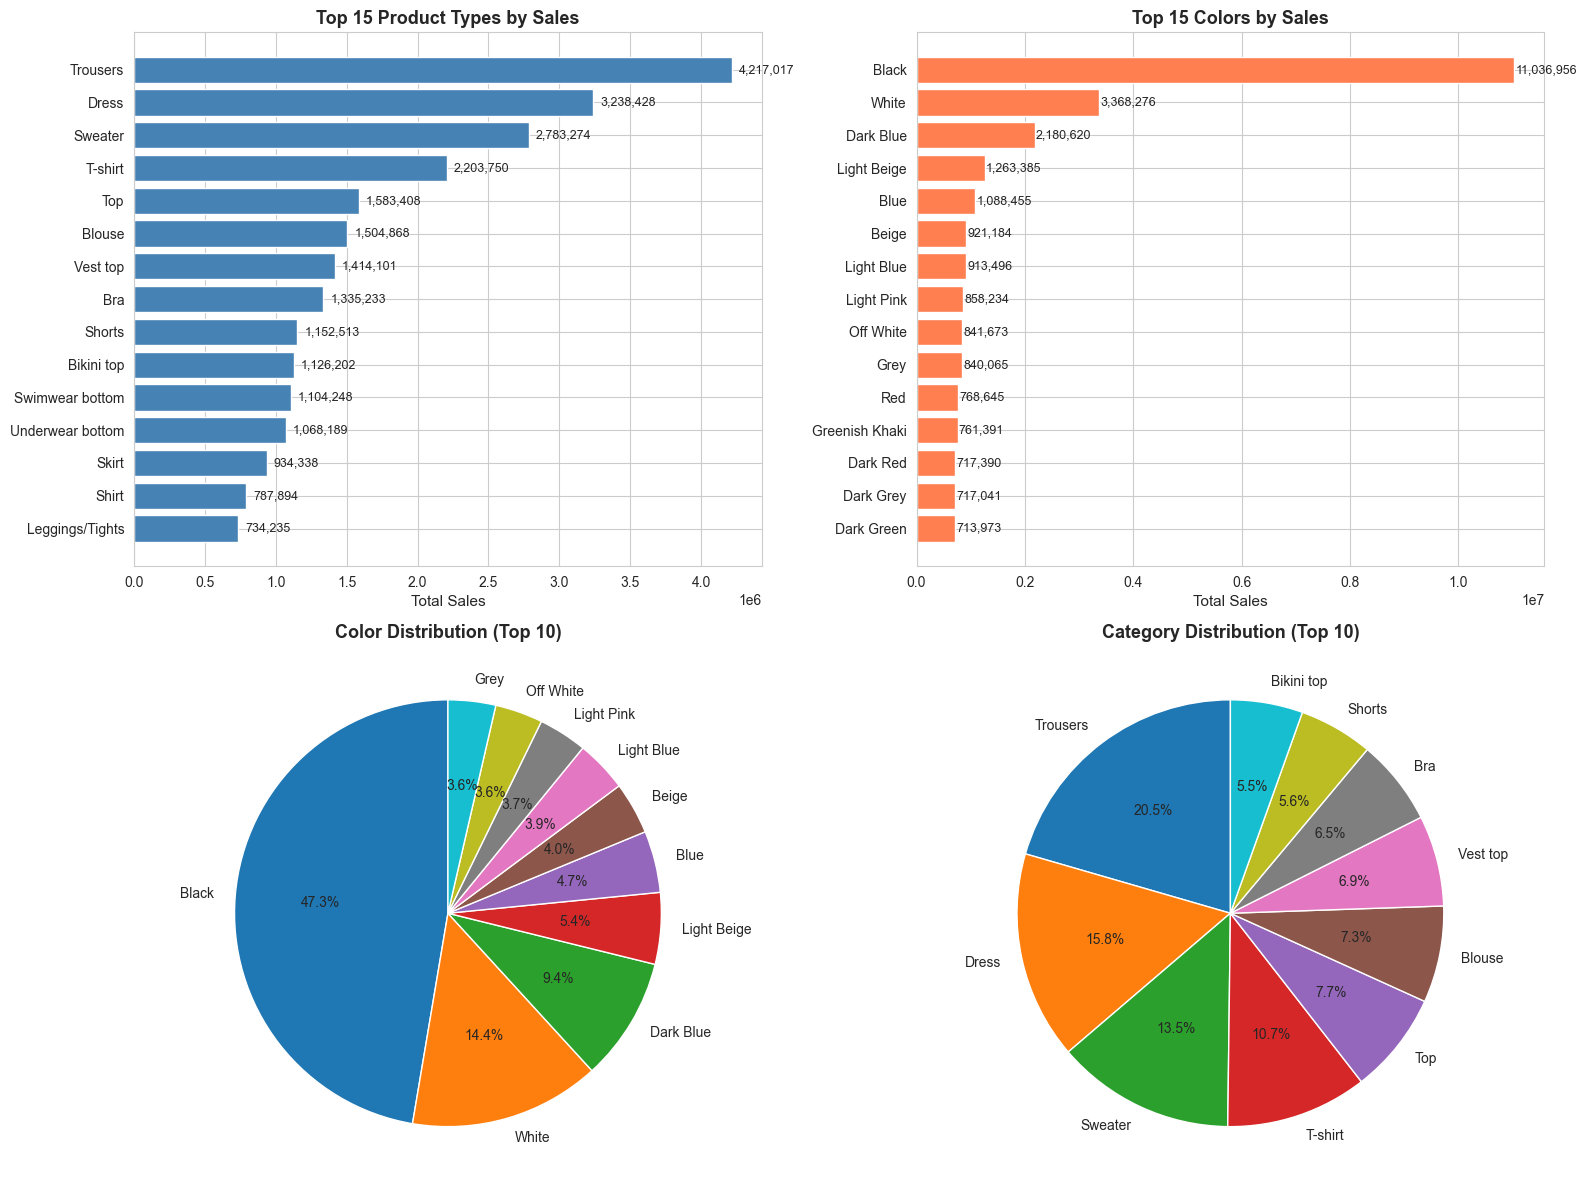

Visualizations complete!


In [23]:
# 1. Top 15 Categories Bar Chart
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Category Distribution
category_sales_sorted = category_sales_agg.head(15)
ax1 = axes[0, 0]
ax1.barh(category_sales_sorted['product_type_name'], category_sales_sorted['total_sales'], color='steelblue')
ax1.set_xlabel('Total Sales', fontsize=11)
ax1.set_title('Top 15 Product Types by Sales', fontsize=13, fontweight='bold')
ax1.invert_yaxis()
for i, v in enumerate(category_sales_sorted['total_sales']):
    ax1.text(v + 50000, i, f'{int(v):,}', va='center', fontsize=9)

# Color Distribution
color_sales_sorted = color_sales_agg.head(15)
ax2 = axes[0, 1]
ax2.barh(color_sales_sorted['colour_group_name'], color_sales_sorted['total_sales'], color='coral')
ax2.set_xlabel('Total Sales', fontsize=11)
ax2.set_title('Top 15 Colors by Sales', fontsize=13, fontweight='bold')
ax2.invert_yaxis()
for i, v in enumerate(color_sales_sorted['total_sales']):
    ax2.text(v + 20000, i, f'{int(v):,}', va='center', fontsize=9)

# Color Pie Chart (Top 10)
color_top_10 = color_sales_agg.head(10)
ax3 = axes[1, 0]
ax3.pie(color_top_10['total_sales'], labels=color_top_10['colour_group_name'], 
        autopct='%1.1f%%', startangle=90)
ax3.set_title('Color Distribution (Top 10)', fontsize=13, fontweight='bold')

# Category Pie Chart (Top 10)
category_top_10 = category_sales_agg.head(10)
ax4 = axes[1, 1]
ax4.pie(category_top_10['total_sales'], labels=category_top_10['product_type_name'], 
        autopct='%1.1f%%', startangle=90)
ax4.set_title('Category Distribution (Top 10)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print("Visualizations complete!")

In [24]:
print("\n" + "=" * 70)
print("CATEGORY ANALYSIS - KEY INSIGHTS")
print("=" * 70)

print(f"\n1. CATEGORY INSIGHTS:")
print(f"   • Total product types: 131")
print(f"   • Top 3 categories: Trousers (13.3%), Dress (10.2%), Sweater (8.8%)")
print(f"   • Top 5 categories account for: {category_sales_agg.head(5)['total_sales'].sum() / len(transactions) * 100:.1f}% of sales")

print(f"\n2. COLOR INSIGHTS:")
print(f"   • Total unique colors: 50")
print(f"   • Black dominates: 34.7% of all sales! (Pareto-like)")
print(f"   • Top 3 colors: Black (34.7%), White (10.6%), Dark Blue (6.9%)")
print(f"   • Neutral colors (Black, White, Grey, Beige, Blue): {((11036956 + 3368276 + 840065 + 921184 + 1088455) / len(transactions) * 100):.1f}% of sales")

print(f"\n3. DEPARTMENT INSIGHTS:")
print(f"   • Total departments: 250")
print(f"   • Top department: Jersey (4.4% of catalog)")
print(f"   • Highly fragmented: Each department small share")

print(f"\n4. BUSINESS RECOMMENDATIONS:")
print(f"   ✓ Focus on Trousers, Dress, Sweater (top sellers)")
print(f"   ✓ Stock primarily Black items (1/3 of all sales!)")
print(f"   ✓ Neutral colors safe bet (70%+ of sales)")
print(f"   ✓ Niche departments: Low priority for stocking")


CATEGORY ANALYSIS - KEY INSIGHTS

1. CATEGORY INSIGHTS:
   • Total product types: 131
   • Top 3 categories: Trousers (13.3%), Dress (10.2%), Sweater (8.8%)
   • Top 5 categories account for: 44.1% of sales

2. COLOR INSIGHTS:
   • Total unique colors: 50
   • Black dominates: 34.7% of all sales! (Pareto-like)
   • Top 3 colors: Black (34.7%), White (10.6%), Dark Blue (6.9%)
   • Neutral colors (Black, White, Grey, Beige, Blue): 54.3% of sales

3. DEPARTMENT INSIGHTS:
   • Total departments: 250
   • Top department: Jersey (4.4% of catalog)
   • Highly fragmented: Each department small share

4. BUSINESS RECOMMENDATIONS:
   ✓ Focus on Trousers, Dress, Sweater (top sellers)
   ✓ Stock primarily Black items (1/3 of all sales!)
   ✓ Neutral colors safe bet (70%+ of sales)
   ✓ Niche departments: Low priority for stocking
